In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import random
import numpy as np
import networkx as nx
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from matplotlib.gridspec import GridSpec

In [21]:
patriotic_alternative_nodes = pd.read_csv("Patriotic_Alternative_Nodes.csv")
Patriotic_Alternative = pd.read_csv("Patriotic_Alternative_Edge.csv")

In [22]:
middle_node_ids = patriotic_alternative_nodes[
    (patriotic_alternative_nodes['lat'] == 53.666612) & 
    (patriotic_alternative_nodes['lng'] == -13.222169)
]['Id'].tolist()

trans_nodes = patriotic_alternative_nodes[
    (patriotic_alternative_nodes['lat'] == 53.562336) & 
    (patriotic_alternative_nodes['lng'] == -20.691347)
]['Id'].tolist()

regional_nodes = patriotic_alternative_nodes[
    
    ~((patriotic_alternative_nodes['lat'] == 53.666612) & (patriotic_alternative_nodes['lng'] == -13.222169)) &
    ~((patriotic_alternative_nodes['lat'] == 53.562336) & (patriotic_alternative_nodes['lng'] == -20.691347))
]['Id'].tolist()

In [23]:
def label_node(node_id):
    if node_id in middle_node_ids:
        return 'Patriotic Alternative National'
    elif node_id in trans_nodes:
        return 'International'
    elif node_id in regional_nodes:
        return 'Patriotic Alternative City'
    else:
        return 'Unknown'

In [24]:
Patriotic_Alternative['PA_Source'] = Patriotic_Alternative['Source'].apply(label_node)
Patriotic_Alternative['PA_Target'] = Patriotic_Alternative['Target'].apply(label_node)

# Check the result
print(Patriotic_Alternative.head())

         Date    source_node    target_node source_sns target_sns  \
0  2021-08-05  Node_88fcf1df  Node_d79a0f32         TG         TG   
1  2021-01-22  Node_639d7cdb  Node_5e66cdb3     Rumble   Bitchute   
2  2021-01-24  Node_dd8534e3  Node_5e66cdb3     Rumble   Bitchute   
3  2020-12-01  Node_ce6b0977  Node_30ed85c2   Bitchute   Bitchute   
4  2020-12-01  Node_ce6b0977  Node_5e66cdb3   Bitchute   Bitchute   

         Source             Target   PA      PA_Source  \
0       TG__146        TG__1008789  NaN  International   
1     Rumble__7       Bitchute__29  NaN  International   
2    Rumble__47       Bitchute__29  NaN  International   
3  Bitchute__50  Bitchute__1000138  NaN  International   
4  Bitchute__50       Bitchute__29  NaN  International   

                        PA_Target  
0  Patriotic Alternative National  
1  Patriotic Alternative National  
2  Patriotic Alternative National  
3  Patriotic Alternative National  
4  Patriotic Alternative National  


In [25]:
patriotic_alternative_nodes['layer'] = 'trans'
patriotic_alternative_nodes.loc[patriotic_alternative_nodes['Id'].isin(middle_node_ids), 'layer'] = 'middle'
patriotic_alternative_nodes.loc[patriotic_alternative_nodes['Id'].isin(trans_nodes), 'layer'] = 'trans'
patriotic_alternative_nodes.loc[patriotic_alternative_nodes['Id'].isin(regional_nodes), 'layer'] = 'regional'


In [11]:
G = nx.Graph()

# Add nodes with attributes
for _, row in patriotic_alternative_nodes.iterrows():
    G.add_node(row['Id'], layer=row['layer'], lat=row['lat'], lng=row['lng'], label=row['Label'])

# Add edges
for _, row in Patriotic_Alternative.iterrows():
    G.add_edge(row['Source'], row['Target'])

In [12]:
middle_layer_nodes = [node for node, data in G.nodes(data=True) if data.get('layer') == 'middle']
all_nodes = [node for node, data in G.nodes(data=True)]

In [13]:
initial_largest_component = max(nx.connected_components(G), key=len)
initial_component_size = len(initial_largest_component)
initial_avg_path_length = nx.average_shortest_path_length(G.subgraph(initial_largest_component))
initial_global_efficiency = nx.global_efficiency(G)

In [ ]:
fragmentation_results_middle = []
G_middle = G.copy()

## Patriotic Alternative National nodes removal

for node in middle_layer_nodes[:10]:
    G_middle.remove_node(node)
    
    largest_component = max(nx.connected_components(G_middle), key=len)
    component_size = len(largest_component)
    avg_path_length = nx.average_shortest_path_length(G_middle.subgraph(largest_component))
    diameter = nx.diameter(G_middle.subgraph(largest_component))
    
    laplacian_matrix = nx.laplacian_matrix(G_middle.subgraph(largest_component)).todense()
    eigenvalues = np.linalg.eigvalsh(laplacian_matrix)
    algebraic_connectivity = sorted(eigenvalues)[1] if len(eigenvalues) > 1 else 0
    
    fragmentation_results_middle.append({
        'step': len(fragmentation_results_middle) + 1,
        'largest_component_size': component_size,
        'average_path_length': avg_path_length,
        'diameter': diameter,
        'algebraic_connectivity': algebraic_connectivity
    })

df_fragmentation_middle = pd.DataFrame(fragmentation_results_middle)

NameError: name 'G' is not defined

In [ ]:
all_random_results = []

## 100 Iteration of randomly removing 10 nodes

for i in range(100):
    G_random = G.copy()
    random_nodes = sorted(random.sample(list(G_random.nodes()), 10))

    
    for j, node in enumerate(random_nodes, 1):
        G_random.remove_node(node)
        
        largest_component = max(nx.connected_components(G_random), key=len)
        component_size = len(largest_component)
        avg_path_length = nx.average_shortest_path_length(G_random.subgraph(largest_component))
        diameter = nx.diameter(G_random.subgraph(largest_component))
        
        laplacian_matrix = nx.laplacian_matrix(G_random.subgraph(largest_component)).todense()
        eigenvalues = np.linalg.eigvalsh(laplacian_matrix)
        algebraic_connectivity = sorted(eigenvalues)[1] if len(eigenvalues) > 1 else 0
        
        all_random_results.append({
            'iteration': i,
            'step': j,
            'largest_component_size': component_size,
            'average_path_length': avg_path_length,
            'diameter': diameter,
            'algebraic_connectivity': algebraic_connectivity
        })

df_fragmentation_random = pd.DataFrame(all_random_results)


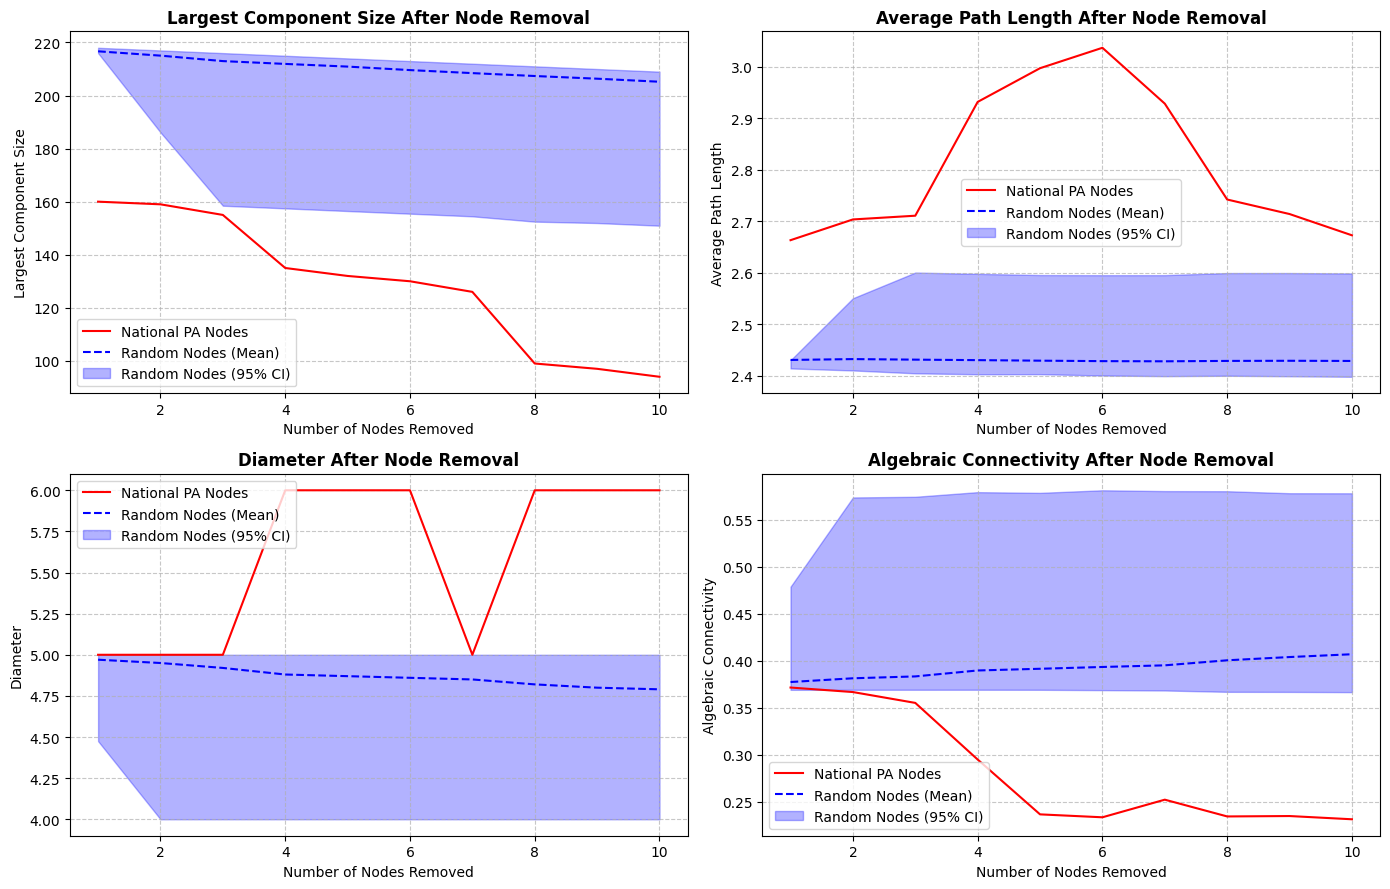

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
metrics = ['largest_component_size', 'average_path_length', 'diameter', 'algebraic_connectivity']
titles = ['Largest Component Size', 'Average Path Length', 'Diameter', 'Algebraic Connectivity']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    row, col = divmod(idx, 2)  
    
   
    axs[row, col].plot(df_fragmentation_middle['step'], df_fragmentation_middle[metric], 'r-', label='National PA Nodes')
    
    
    grouped = df_fragmentation_random.groupby('step')[metric]
    mean = grouped.mean()
    lower = grouped.quantile(0.025)
    upper = grouped.quantile(0.975)
    
   
    axs[row, col].plot(mean.index, mean.values, 'b--', label='Random Nodes (Mean)')
    
    axs[row, col].fill_between(mean.index, lower, upper,
                            alpha=0.3, color='b',
                            label='Random Nodes (95% CI)')
    
  
    
    

    axs[row, col].set_title(f'{title} After Node Removal', fontweight='bold')
    axs[row, col].set_xlabel('Number of Nodes Removed')
    axs[row, col].set_ylabel(title)
    axs[row, col].grid(True, linestyle='--', alpha=0.7)
    
    
    if idx == 0:  # Only for the first plot to avoid redundancy
        handles, labels = axs[row, col].get_legend_handles_labels()
       
        unique_labels = []
        unique_handles = []
        for i, label in enumerate(labels):
            if label not in unique_labels:
                unique_labels.append(label)
                unique_handles.append(handles[i])
        axs[row, col].legend(unique_handles, unique_labels)
    else:
        axs[row, col].legend()


plt.tight_layout(rect=[0, 0.05, 1, 0.95]) 

plt.savefig("network_dismantling_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

## City Platform Analysis

In [55]:
## Platform distribution of city nodes
city_platform_distribution = patriotic_alternative_nodes[patriotic_alternative_nodes['layer'] == 'regional']['SNS'].value_counts()

In [56]:
city_platform_distribution

SNS
TG         10
Odysee      4
Gab         4
YouTube     2
Name: count, dtype: int64

In [57]:
Patriotic_Alternative[Patriotic_Alternative['Target'].isin(regional_nodes)]['Source'].unique().tolist()

['TG__482',
 'TG__140',
 'TG__74',
 'TG__154',
 'TG__122',
 'TG__27',
 'Gab__18',
 'TG__240',
 'TG__404',
 'Gab__10',
 'TG__313',
 'TG__500',
 'TG__497',
 'TG__218',
 'TG__321',
 '4Chan__1',
 'TG__325',
 'TG__447',
 'TG__503',
 'Gab__31',
 'TG__158',
 'Gab__5',
 'Gab__411',
 'TG__84']

In [58]:
## Platform distribution of nodes targettign city nodes

target_platform_distribution = patriotic_alternative_nodes[patriotic_alternative_nodes['Id'].isin(Patriotic_Alternative[Patriotic_Alternative['Target'].isin(regional_nodes)]['Source'].unique().tolist())]['SNS'].value_counts()

In [59]:
platform_city = list(city_platform_distribution.index)
platform_target = list(target_platform_distribution.index)

In [60]:
platform_city = ['Telegram' if platform == 'TG' else platform for platform in platform_city]
platform_target = ['Telegram' if platform == 'TG' else platform for platform in platform_target]

# Combine platforms from both lists and create a unique color mapping
unique_platforms = list(set(platform_city + platform_target))
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_platforms)))  # Use tab20 colormap for distinct colors

# Create a dictionary to map each unique platform to a color
color_mapping = dict(zip(unique_platforms, colors))

# Function to show absolute values in the pie chart
def absolute_value(val, values):
    a = int(round(val / 100. * sum(values)))
    return f'{a:,}'



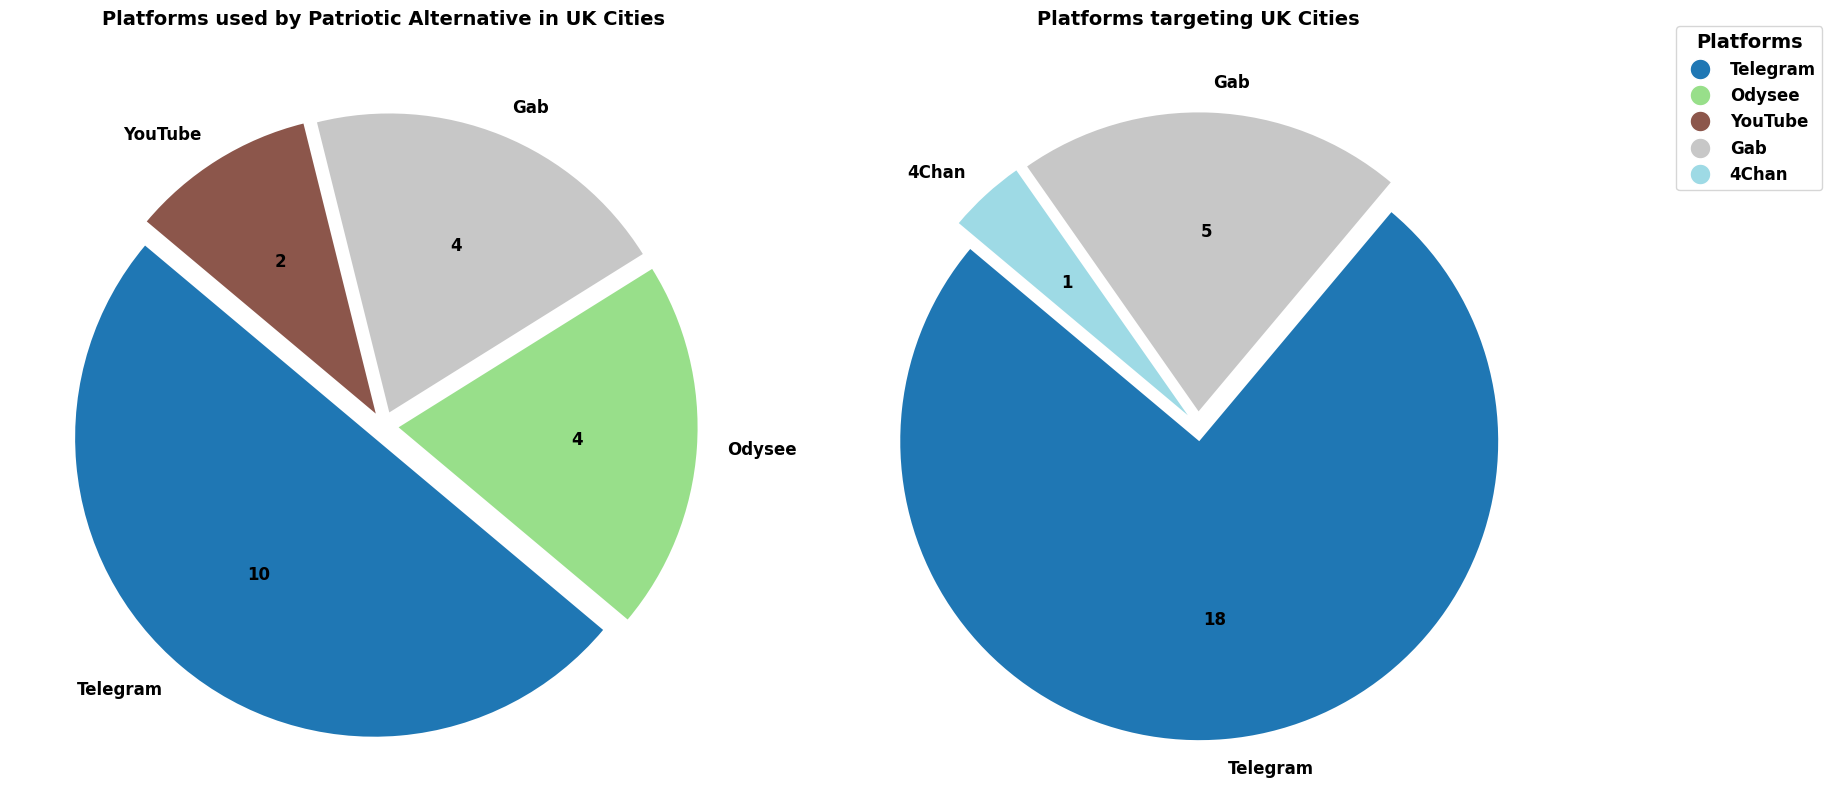

In [61]:
# Increase font sizes and make text bold
plt.rcParams['font.size'] = 12
plt.rcParams['font.weight'] = 'bold'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Plot for City Nodes
ax1.pie(city_platform_distribution.values, labels=platform_city, 
        autopct=lambda val: absolute_value(val, city_platform_distribution.values),
        colors=[color_mapping[platform] for platform in platform_city], 
        startangle=140, shadow=False, explode=[0.05] * len(platform_city),
        textprops={'fontsize': 12, 'fontweight': 'bold'})
ax1.set_title('Platforms used by Patriotic Alternative in UK Cities', pad=20, fontsize=14, fontweight='bold')

# Plot for Nodes Targeting Cities
ax2.pie(target_platform_distribution.values, labels=platform_target, 
        autopct=lambda val: absolute_value(val, target_platform_distribution.values),
        colors=[color_mapping[platform] for platform in platform_target], 
        startangle=140, shadow=False, explode=[0.05] * len(platform_target),
        textprops={'fontsize': 12, 'fontweight': 'bold'})
ax2.set_title('Platforms targeting UK Cities', pad=20, fontsize=14, fontweight='bold')

# Create legend with larger size
legend_handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_mapping[platform], markersize=15)
                  for platform in unique_platforms]

# Position legend at top right with larger font
fig.legend(legend_handles, unique_platforms, 
          loc="upper right", 
          title="Platforms",
          bbox_to_anchor=(1.15, 1.0),
          fontsize=12,
          title_fontsize=14,
          prop={'weight': 'bold'})

# Adjust layout
plt.tight_layout()
plt.show()